Detected label column: label
Total samples: 1533

  label  count  percent
  anger    474    30.92
neutral    395    25.77
sadness    266    17.35
    joy    188    12.26
   love    153     9.98
   fear     57     3.72


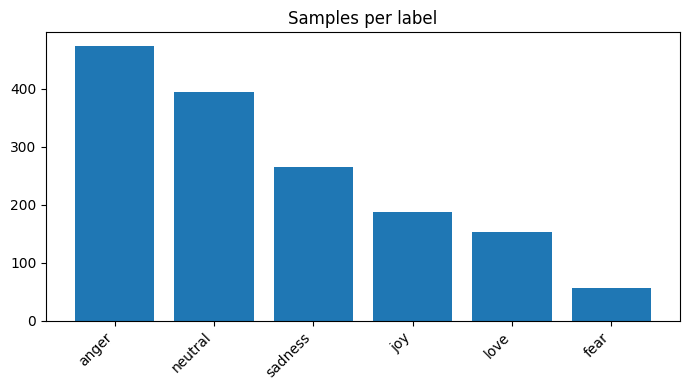


Saved: emotionalturk_label_counts.csv


In [1]:
# Show sample count per label for EmotionalTurk
import re
import pandas as pd
import matplotlib.pyplot as plt

PATH = "/kaggle/input/emotionalturk/EmotionalTurk.csv"

df = pd.read_csv(PATH)

# Heuristic: pick the most likely label column
candidates = [c for c in df.columns if re.search(r'(label|emotion|class|target)', c, re.I)]
priority = ['label','emotion','emotions','labels','target','class']
label_col = next((c for p in priority for c in df.columns if c.lower()==p), None)
if label_col is None:
    if not candidates:
        raise ValueError(f"No label-like column found. Columns: {list(df.columns)}")
    label_col = candidates[0]

# Clean & count
df[label_col] = df[label_col].astype(str).str.strip()
counts = (
    df[label_col].value_counts(dropna=False)
      .rename_axis(label_col)
      .reset_index(name='count')
)
counts['percent'] = (counts['count'] / len(df) * 100).round(2)

print(f"Detected label column: {label_col}")
print(f"Total samples: {len(df)}\n")
print(counts.to_string(index=False))

# Optional: bar chart
plt.figure(figsize=(7,4))
counts_sorted = counts.sort_values('count', ascending=False)
plt.bar(counts_sorted[label_col].astype(str), counts_sorted['count'])
plt.title('Samples per label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Save the table
counts_sorted.to_csv('emotionalturk_label_counts.csv', index=False)
print("\nSaved: emotionalturk_label_counts.csv")

Detected label column: Etiket
Total samples: 4000

 Etiket  count  percent
 kızgın    800     20.0
  korku    800     20.0
  mutlu    800     20.0
surpriz    800     20.0
  üzgün    800     20.0


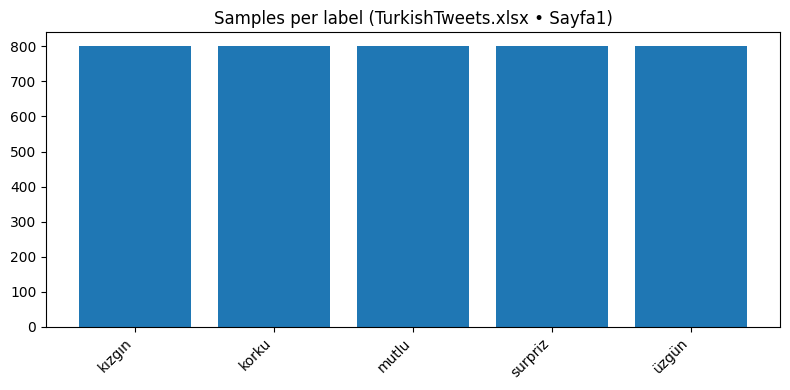


Saved: turkish_tweets_label_counts.csv


In [2]:
# Sample count per label for TurkishTweets.xlsx (sheet: Sayfa1)
import re
import pandas as pd
import matplotlib.pyplot as plt

PATH = "/kaggle/input/turkish-tweet-dataset/TurkishTweets.xlsx"
SHEET = "Sayfa1"  # change if needed, e.g. to another sheet name

# --- Load Excel (robust to missing sheet) ---
xls = pd.ExcelFile(PATH)
if SHEET not in xls.sheet_names:
    raise ValueError(f"Sheet '{SHEET}' not found. Available: {xls.sheet_names}")
df = pd.read_excel(xls, sheet_name=SHEET)

# --- Heuristic label column detection (EN + TR keywords) ---
priority = [
    'label','labels','emotion','emotions','sentiment','polarity',
    'target','class','category','kategori',
    'duygu','etiket','hedef','sınıf','sinif'
]
priority_lc = [p.lower() for p in priority]
label_col = next((c for c in df.columns if c.lower() in priority_lc), None)
if label_col is None:
    candidates = [c for c in df.columns if re.search(r'(label|emotion|sentiment|polarity|target|class|kategori|duygu|etiket|hedef|s(ı|i)n(ı|i)f)', c, re.I)]
    if not candidates:
        raise ValueError(f"No label-like column found. Columns: {list(df.columns)}")
    label_col = candidates[0]

# --- Count & percentage ---
df[label_col] = df[label_col].astype(str).str.strip()
counts = (
    df[label_col].value_counts(dropna=False)
      .rename_axis(label_col)
      .reset_index(name='count')
)
counts['percent'] = (counts['count'] / len(df) * 100).round(2)

print(f"Detected label column: {label_col}")
print(f"Total samples: {len(df)}\n")
print(counts.to_string(index=False))

# --- Bar chart ---
plt.figure(figsize=(8,4))
ordered = counts.sort_values('count', ascending=False)
plt.bar(ordered[label_col].astype(str), ordered['count'])
plt.title('Samples per label (TurkishTweets.xlsx • Sayfa1)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Save to CSV ---
out_path = 'turkish_tweets_label_counts.csv'
ordered.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")


=== /kaggle/input/turkish-emotion-dataset/Emotion_dataset_test.csv ===
Detected label column: label
Total samples: 100

  label  count  percent
  üzgün     25     25.0
  korku     24     24.0
 kızgın     23     23.0
  mutlu     17     17.0
surpriz     11     11.0


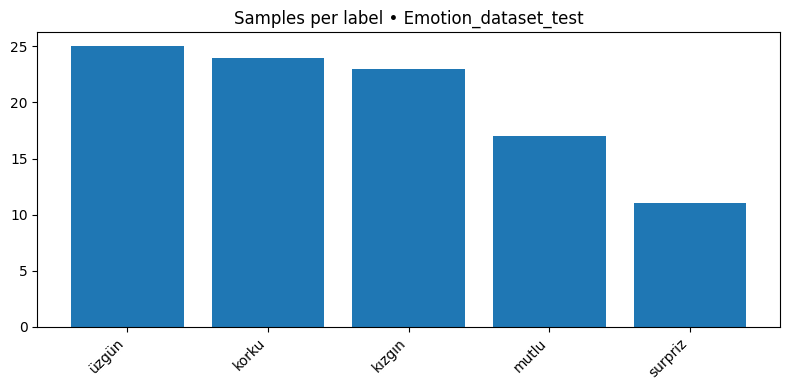

Saved: Emotion_dataset_test_label_counts.csv and Emotion_dataset_test_label_counts.png

=== /kaggle/input/turkish-emotion-dataset/Emotion_dataset_train.csv ===
Detected label column: Label
Total samples: 3900

  Label  count  percent
surpriz    789    20.23
  mutlu    783    20.08
 kızgın    777    19.92
  korku    776    19.90
  üzgün    775    19.87


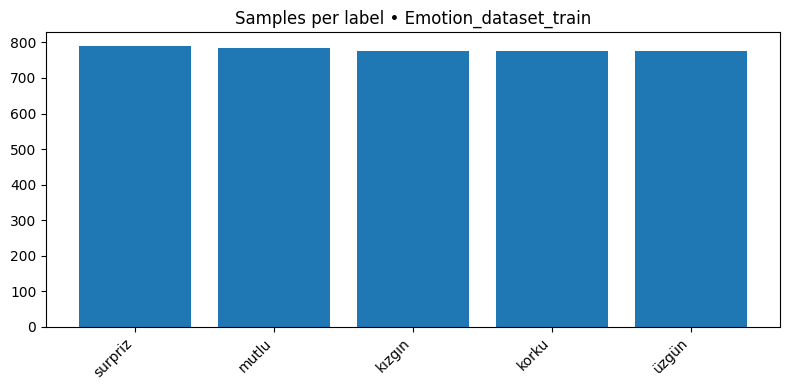

Saved: Emotion_dataset_train_label_counts.csv and Emotion_dataset_train_label_counts.png


In [ ]:
# Label counts for Turkish Emotion dataset (train & test)
import os, re
import pandas as pd
import matplotlib.pyplot as plt

PATHS = [
    "/kaggle/input/turkish-emotion-dataset/Emotion_dataset_test.csv",
    "/kaggle/input/turkish-emotion-dataset/Emotion_dataset_train.csv",
]

# --- Heuristic: detect label column ---
PRIORITY = [
    "emotion","emotions","duygu","sentiment","polarity",
    "label","labels","target","class","category","kategori","etiket","hedef","sınıf","sinif"
]
PRIORITY_LC = [p.lower() for p in PRIORITY]

def pick_label_col(df: pd.DataFrame) -> str:
    # exact match by priority (case-insensitive)
    for p in PRIORITY_LC:
        for c in df.columns:
            if c.lower() == p:
                return c
    # regex fallback by keywords
    cands = [c for c in df.columns if re.search(
        r"(emotion|duygu|sentiment|polarity|label|target|class|kategori|etiket|hedef|s(ı|i)n(ı|i)f)",
        c, flags=re.I)]
    if cands:
        return cands[0]
    # last resort: pick the column with the fewest unique values (typical of labels)
    return df.nunique().sort_values().index[0]

def count_and_plot(df: pd.DataFrame, file_path: str):
    label_col = pick_label_col(df)
    df[label_col] = df[label_col].astype(str).str.strip()

    counts = (
        df[label_col].value_counts(dropna=False)
          .rename_axis(label_col)
          .reset_index(name="count")
    )
    counts["percent"] = (counts["count"] / len(df) * 100).round(2)

    base = os.path.splitext(os.path.basename(file_path))[0]
    out_csv = f"{base}_label_counts.csv"
    out_png = f"{base}_label_counts.png"

    print(f"\n=== {file_path} ===")
    print(f"Detected label column: {label_col}")
    print(f"Total samples: {len(df)}\n")
    print(counts.to_string(index=False))

    # Plot
    ordered = counts.sort_values("count", ascending=False)
    plt.figure(figsize=(8,4))
    plt.bar(ordered[label_col].astype(str), ordered["count"])
    plt.title(f"Samples per label • {base}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()

    ordered.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv} and {out_png}")

# --- Run on all paths ---
for p in PATHS:
    df = pd.read_csv(p)
    count_and_plot(df, p)

Total <Doc> records: 27350

=== ValidatedEmotion counts ===
ValidatedEmotion  count  percent
           Happy   5229    19.12
         Sadness   5021    18.36
           Anger   4723    17.27
            Fear   4393    16.06
         Disgust   3620    13.24
        Surprise   3003    10.98
       Ambigious   1361     4.98

=== OriginalEmotion counts ===
OriginalEmotion  count  percent
          Happy   4700    17.18
        Sadness   4664    17.05
          Anger   4636    16.95
           Fear   4616    16.88
        Disgust   4522    16.53
       Surprise   4212    15.40

=== Condition counts (e.g., Consensus) ===
        Condition  count  percent
        Consensus  19462    71.16
Majority of Votes   6527    23.86
           Reject   1361     4.98

Saved: TREMODATA_validated_label_counts.csv, TREMODATA_original_label_counts.csv, TREMODATA_condition_counts.csv


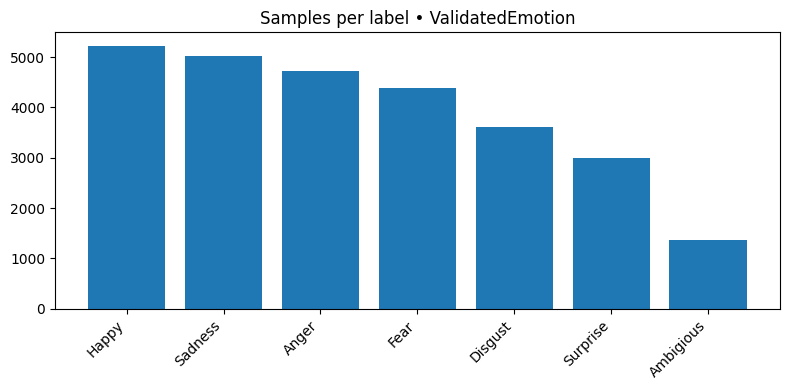

Saved: TREMO_validated_label_counts.png


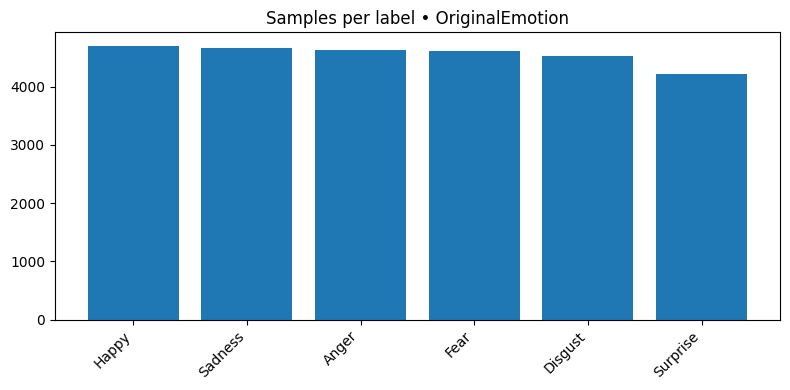

Saved: TREMO_original_label_counts.png


In [4]:
# Label counts for TREMO XML (ValidatedEmotion & OriginalEmotion)
import os
import xml.etree.ElementTree as ET
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

PATH = "/kaggle/input/tremo/TREMODATA.xml"

def local(tag):
    """Return tag without XML namespace, if any."""
    return tag.split('}', 1)[-1]

def child_text(elem, name):
    """Get the text of the first child whose local tag == name."""
    for ch in elem:
        if local(ch.tag) == name:
            return (ch.text or "").strip()
    return None

validated_ctr = Counter()
original_ctr = Counter()
condition_ctr = Counter()
total_docs = 0

# Efficient streaming parse
for event, elem in ET.iterparse(PATH, events=("end",)):
    if local(elem.tag) == "Doc":
        total_docs += 1
        val = child_text(elem, "ValidatedEmotion")
        org = child_text(elem, "OriginalEmotion")
        cond = child_text(elem, "Condition")

        if val is not None and val != "":
            validated_ctr[val] += 1
        if org is not None and org != "":
            original_ctr[org] += 1
        if cond is not None and cond != "":
            condition_ctr[cond] += 1

        # free memory for large XML
        elem.clear()

def to_df(counter, col_name, total):
    df = (
        pd.Series(counter, name="count")
          .sort_values(ascending=False)
          .rename_axis(col_name)
          .reset_index()
    )
    df["percent"] = (df["count"] / total * 100).round(2)
    return df

# Build dataframes
df_validated = to_df(validated_ctr, "ValidatedEmotion", total_docs)
df_original  = to_df(original_ctr,  "OriginalEmotion",  total_docs)
df_condition = to_df(condition_ctr, "Condition",        total_docs)

print(f"Total <Doc> records: {total_docs}\n")

print("=== ValidatedEmotion counts ===")
print(df_validated.to_string(index=False))

print("\n=== OriginalEmotion counts ===")
print(df_original.to_string(index=False))

print("\n=== Condition counts (e.g., Consensus) ===")
print(df_condition.to_string(index=False))

# Save CSVs
df_validated.to_csv("TREMODATA_validated_label_counts.csv", index=False)
df_original.to_csv("TREMODATA_original_label_counts.csv", index=False)
df_condition.to_csv("TREMODATA_condition_counts.csv", index=False)
print("\nSaved: TREMODATA_validated_label_counts.csv, TREMODATA_original_label_counts.csv, TREMODATA_condition_counts.csv")

# Plots
def plot_counts(df, label_col, title, out_png):
    if df.empty:
        print(f"Skip plot: no data for {label_col}")
        return
    plt.figure(figsize=(8,4))
    ordered = df.sort_values("count", ascending=False)
    plt.bar(ordered[label_col].astype(str), ordered["count"])
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()
    print(f"Saved: {out_png}")

plot_counts(df_validated, "ValidatedEmotion", "Samples per label • ValidatedEmotion", "TREMO_validated_label_counts.png")
plot_counts(df_original,  "OriginalEmotion",  "Samples per label • OriginalEmotion",  "TREMO_original_label_counts.png")